### Hype

#### 一,核心动机:解决问题与文档的"不对称性"
在基础 RAG 中，我们直接把用户的问题转化为向量去搜文档。但这里存在一个本质的矛盾：  

- 特征差异：用户的问题通常很短、措辞可能不专业甚至有误
- 文档特征：索引库里的文档块通常是很长、密集且充满专业术语的段落  
  
后果：由于这种“不对称性”，在某些复杂的语义空间里，原始问题向量可能距离它真正的答案向量非常远，导致检索失败

#### 二,Hype 核心逻辑为以假寻真  
既然问题和文档不像，那我就先让 LLM 把问题翻译成一个“假设性的答案”
1. 映射到文档空间：与其用“问题”去搜“答案”，不如用一个“假设的答案”去搜“真实的答案”。
2. 语义对齐：LLM 凭借其内部的知识储备（World Knowledge），虽然可能无法给出完全准确的事实，但它生成的“假设性文档”在遣词造句、术语表达和逻辑结构上，会和数据库里的真实文档非常接近。
3. 检索优势：在向量空间中，这个“假设性文档”往往比原始的“短问题”更靠近目标文档

#### 三,Hype的步骤
1. 编写假设文档：给 LLM 一个特定的 Prompt（例如：“请写一段论文段落来回答这个问题”），让它凭空生成一个答案。
2. 向量化（Embedding）：对这个生成的“假答案”进行嵌入处理。
3. 检索（Retrieval）：拿这个“假答案”的向量去向量库中检索最相似的真实文档块。
4. 生成最终答案：最后，LLM 结合检索回来的“真资料”和用户最初的“真问题”，给出一个准确且基于事实的回答

In [1]:
# Indexing
import bs4
from langchain_community.document_loaders import WebBaseLoader
loader = WebBaseLoader(
    web_paths=("https://lilianweng.github.io/posts/2023-06-23-agent/",),
    bs_kwargs=dict(
        parse_only=bs4.SoupStrainer(
            class_=("post-content", "post-title", "post-header")
        )
    ),
)
blog_docs = loader.load()
print(blog_docs)


c:\Users\23017\anaconda3\envs\rag_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
USER_AGENT environment variable not set, consider setting it to identify your requests.


[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='\n\n      LLM Powered Autonomous Agents\n    \nDate: June 23, 2023  |  Estimated Reading Time: 31 min  |  Author: Lilian Weng\n\n\nBuilding agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview#\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistake

In [2]:
#Split
from langchain_text_splitters import CharacterTextSplitter
text_splitter = CharacterTextSplitter(chunk_size=300, chunk_overlap=50)
splits = text_splitter.split_documents(blog_docs)  
print(splits)  # 打印分割后的 Document 对象列表

Created a chunk of size 492, which is longer than the specified 300
Created a chunk of size 341, which is longer than the specified 300
Created a chunk of size 336, which is longer than the specified 300
Created a chunk of size 2671, which is longer than the specified 300
Created a chunk of size 716, which is longer than the specified 300
Created a chunk of size 620, which is longer than the specified 300
Created a chunk of size 1373, which is longer than the specified 300
Created a chunk of size 738, which is longer than the specified 300
Created a chunk of size 1281, which is longer than the specified 300
Created a chunk of size 363, which is longer than the specified 300
Created a chunk of size 344, which is longer than the specified 300
Created a chunk of size 398, which is longer than the specified 300
Created a chunk of size 370, which is longer than the specified 300
Created a chunk of size 542, which is longer than the specified 300
Created a chunk of size 2352, which is longer

[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='LLM Powered Autonomous Agents\n    \nDate: June 23, 2023  |  Estimated Reading Time: 31 min  |  Author: Lilian Weng'), Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview#\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:'), Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='Planning'), Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-0

In [3]:
from langchain_community.vectorstores import Chroma
from langchain_community.embeddings import HuggingFaceEmbeddings
EMBEDDING_MODEL = "all-MiniLM-L6-v2"  # 免费嵌入模型

embeddings = HuggingFaceEmbeddings(
    model_name=EMBEDDING_MODEL,
    model_kwargs={"device": "cpu"},  # 仅用CPU，无需GPU
    encode_kwargs={"normalize_embeddings": True}  # 归一化向量，提升检索精度
)
vectorstore = Chroma.from_documents(
    documents=splits,
    embedding=embeddings,
    persist_directory="./chroma_db"  # 向量库保存路径
)
vectorstore.persist()  # 持久化存储
retriever = vectorstore.as_retriever() 

C:\Users\23017\AppData\Local\Temp\ipykernel_11740\2382097115.py:5: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1270.58it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
C:\Users\23017\AppData\Local\Temp\ipykernel_11740\2382097115.py:15: LangChainDep

In [7]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_community.chat_models.tongyi import ChatTongyi
import os 
from langchain_core.output_parsers import StrOutputParser
DASHSCOPE_API_KEY = "sk-bb5a3bc665be4d35bea3efce0196c8c1"
os.environ["DASHSCOPE_API_KEY"] = DASHSCOPE_API_KEY
CHUNK_SIZE = 1000  # 文本分块大小
CHUNK_OVERLAP = 200  # 分块重叠长度
EMBEDDING_MODEL = "all-MiniLM-L6-v2"  # 免费嵌入模型
LLM_MODEL = "qwen-turbo"  # 通义千问免费模型
TEMPERATURE = 0.0  # 生成温度（0=稳定输出）
llm = ChatTongyi(
    model=LLM_MODEL,
    temperature=TEMPERATURE,
    dashscope_api_key=DASHSCOPE_API_KEY
)
# HyDE document generation
template = """Please write a scientific paper passage to answer the question
Question: {question}
Passage:"""
prompt_hyde = ChatPromptTemplate.from_template(template)

from langchain_core.output_parsers import StrOutputParser

generate_docs_for_retrieval = (
    prompt_hyde | llm | StrOutputParser() 
)

# Run
question = "What is task decomposition for LLM agents?请用中文回答"
generate_docs_for_retrieval.invoke({"question":question})

'任务分解（Task Decomposition）是指将一个复杂任务拆解为多个更小、更易处理的子任务的过程。对于大型语言模型（LLM）代理而言，任务分解是实现高效问题解决和决策制定的关键机制之一。通过将整体目标分解为一系列可操作的步骤，LLM代理能够更有效地规划行动路径、分配资源，并逐步完成复杂的任务。这种分解过程通常依赖于对任务结构的深入理解以及对子任务之间依赖关系的明确识别。在实际应用中，任务分解可以显著提升LLM代理的执行效率与准确性，尤其是在面对多步骤、多阶段或高度不确定性的任务时。此外，任务分解还支持模块化设计，使得系统能够灵活应对变化，并通过并行处理提高整体性能。因此，任务分解不仅是LLM代理实现复杂任务处理的核心技术之一，也是提升其智能水平和自主性的重要手段。'

In [8]:
retrieval_chain = generate_docs_for_retrieval | retriever 
retrieved_docs = retrieval_chain.invoke({"question":question})
print(retrieved_docs)

[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='Component One: Planning#\nA complicated task usually involves many steps. An agent needs to know what they are and plan ahead.\nTask Decomposition#\nChain of thought (CoT; Wei et al. 2022) has become a standard prompting technique for enhancing model performance on complex tasks. The model is instructed to “think step by step” to utilize more test-time computation to decompose hard tasks into smaller and simpler steps. CoT transforms big tasks into multiple manageable tasks and shed lights into an interpretation of the model’s thinking process.\nTree of Thoughts (Yao et al. 2023) extends CoT by exploring multiple reasoning possibilities at each step. It first decomposes the problem into multiple thought steps and generates multiple thoughts per step, creating a tree structure. The search process can be BFS (breadth-first search) or DFS (depth-first search) with each state evaluated by a

In [9]:
template = """Answer the following question based on this context:

{context}

Question: {question}
"""

prompt = ChatPromptTemplate.from_template(template)

final_rag_chain = (
    prompt
    | llm
    | StrOutputParser()
)

final_rag_chain.invoke({"context":retrieved_docs,"question":question})

'对于LLM代理而言，任务分解是指将一个复杂的任务拆分成多个较小的、更易管理的子任务。这种方法有助于提高模型在处理复杂任务时的表现。任务分解可以通过以下几种方式实现：\n\n1. 通过简单的提示指令，如“XYZ的步骤。1.”或“如何实现XYZ的子目标？”；\n2. 使用特定于任务的指令，例如为写小说而提供“写一个故事大纲”；\n3. 通过人工输入。\n\n这种分解过程使大任务变得更容易处理，并且可以揭示模型思考过程的解释。'

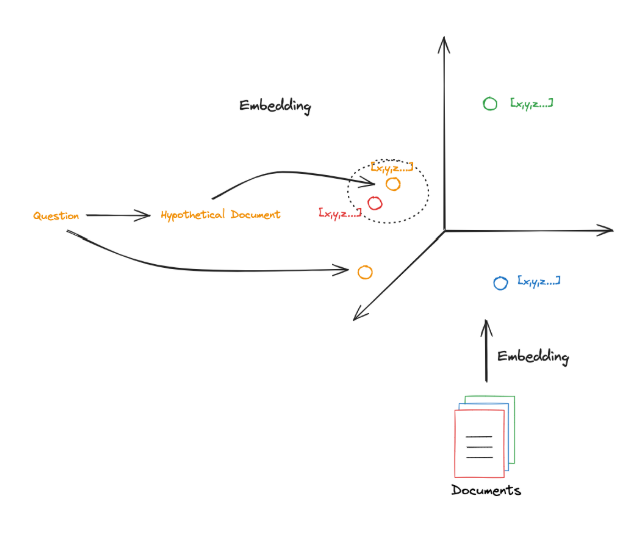